In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import statsmodels.api as sm



from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [3]:
# data directories
root_dir = '/dartfs-hpc/rc/lab/C/CMIG'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'


In [4]:
#conversion factors
cm_to_mm = 10
scale = 0.1

In [5]:
# data processing functions
def detrend_dim(da, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim='water_year', deg=deg)
    fit = xr.polyval(da.water_year, p.polyfit_coefficients)
    return da - fit

def flipLon360(ds):
    # converts -180-180 lon to 0-360
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

def fixLonLine(ds):
    # wrap cyclic point to avoid nans at lon=0 when plotting
    
    # fill the NaNs in the last column with the values from the adjacent column
    last_valid_lon_index = ds.lon.argmax().item()   
    ds[:, last_valid_lon_index] = ds[:, last_valid_lon_index -1].where(np.isnan(ds[:, last_valid_lon_index]), ds[:, last_valid_lon_index])

    return ds

def fixLonLine2(ds):
    # alternative wrap cyclic point to avoid nans at lon=0 when plotting

    # ensure there are valid lon values to process
    if ds.lon.size == 0 or np.isnan(ds.lon).all():
        raise ValueError("Longitude array is empty or all values are NaN.")

    # find the index of the last valid column before lon=0
    valid_lons = ds.lon.values
    last_valid_lon_index = np.nanargmax(valid_lons) - 1  # One before the last

    # last_valid_lon_index is valid
    if last_valid_lon_index < 0:
        raise ValueError("No valid longitude values before 0.")

    # Fill the NaNs in the last column with the values from the adjacent column
    ds[:, last_valid_lon_index] = ds[:, last_valid_lon_index - 1].where(
        np.isnan(ds[:, last_valid_lon_index]), 
        ds[:, last_valid_lon_index]
    )

    return ds


### setup basin shapefile

In [13]:
# load basin shapefile
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')

In [9]:
# load basin scale results and full panel
basin_models = pd.read_csv(save_dir+'basin_models_no_interaction_GPCC.csv')
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')

#load processed basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')

#merge onto full df
pexq_df['basin_id'] = basin_id_df['basin_id']

In [14]:
# gather basin names (for identifying basins)
names = []
for i in basin_models['basin_id']:
    names.append(grdc_basins[grdc_basins.MRBID == i].RIVER_BASI.values[0])

basin_models['basin_name'] = names

In [15]:
#bring in pmean from pexq_df dataset:
#Pmeanlist = []
#for i in basin_models.index:
#    Pmeanlist.append(pexq_df[pexq_df.basin_id == int(basin_models.loc[i].basin_id)].Pmean.mean())

#basin_models['Pmean'] = Pmeanlist

# for interaction model, compute full Gp coef and add to df:
#basin_models['dTWS/dGp'] = basin_models['coef_Gp']+basin_models['coef_Gp_Pmean']*basin_models['Pmean']*scale*cm_to_mm

grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})
merged = grdc_basins.merge(basin_models, on='basin_id', how='left')

### fig 1. characterizing gini

In [21]:
# setup precip and grace tws

# load CPC precip (for plotting sample timeseries) and GRACE
cpc = xr.open_mfdataset(cpc_dir + '*.nc')
grace_ds = xr.open_dataset(save_dir+'GRACE_LWE_wateryear.nc')

# load cpc gp
pr_gini_wy = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')


#trim GRACE to study period, interp grid, 
grace_ds = grace_ds.sel(water_year=np.arange(2002,2022))
grace = grace_ds.interp_like(pr_gini_wy.sel(water_year=2002))

#setup landmask for GRACE
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(grace)
mask = mask.landseamask < 75

# remove incomplete mission water-years and land mask
grace = grace.sel(water_year=~grace.water_year.isin([2002,2017,2022])).where(mask)

#take linear time trend grace, scale to per 20 years
grace_trend = grace.lwe_thickness.polyfit('water_year',deg=1).polyfit_coefficients.sel(degree=1)*(2021-2003+2)

# internnual SD TWS
grace_detrend = detrend_dim(grace.lwe_thickness)
grace_sd = grace_detrend.std('water_year')

#GRACE is in cm, so convert cm to mm to match percip units
grace_sd = grace_sd*cm_to_mm
grace_trend = grace_trend*cm_to_mm



In [23]:
# setup P gini 

#open gini datasets
gp_gpcc = xr.open_dataset(save_dir+'GPCC_daily_pr_gini_water_year_1982-2021.nc')
gp_cpc = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/annual_daily_pr_gini_CPC_1980-2020.nc')
gp_gpcp =  xr.open_dataset(save_dir+'GPCP_daily_pr_gini_water_year_1997-2022.nc')

# climatological average Gp, averaged across datasets
gp_gpcpmean = gp_gpcp.sel(water_year=np.arange(1997,2022)).mean(dim='water_year').Pgini_wy
gp_gpccmean = gp_gpcc.sel(water_year=np.arange(1982,2021)).mean(dim='water_year').Pgini_wy
gp_cpcmean = gp_cpc.sel(year=np.arange(1980,2020)).mean(dim='year').pr_gini

gp_gpcpmean = gp_gpcpmean.interp_like(gp_cpcmean)
gp_gpccmean = gp_gpccmean.interp_like(gp_cpcmean)

gpmean = xr.concat([gp_gpcpmean,gp_cpcmean,gp_gpccmean],dim='product').mean('product')

# select phnom penh from cpc Gp (one product, just for illustration)
gpsub = gp_cpc.sel(lon=slice(107.7,107.9),lat=43.75)
min_gp = gpsub.pr_gini.min()
max_gp = gpsub.pr_gini.max()


In [24]:
# load regression results, hydroclimate drivers of Gp
gpd = pd.read_csv(save_dir+'reg_results/regression_results_drivers_of_Gp.csv')

# take mean, max, and min across datasets
P_mean = np.mean([gpd.coef_P_CPC[0],gpd.coef_P_GPCC[0],gpd.coef_P_GPCP[0]])
P_min = np.min([gpd.coef_P_CPC[0],gpd.coef_P_GPCC[0],gpd.coef_P_GPCP[0]])
P_max = np.max([gpd.coef_P_CPC[0],gpd.coef_P_GPCC[0],gpd.coef_P_GPCP[0]])

T_mean = np.mean([gpd.coef_T_CPC[0],gpd.coef_T_GPCC[0],gpd.coef_T_GPCP[0]])
T_min = np.min([gpd.coef_T_CPC[0],gpd.coef_T_GPCC[0],gpd.coef_T_GPCP[0]])
T_max = np.max([gpd.coef_T_CPC[0],gpd.coef_T_GPCC[0],gpd.coef_T_GPCP[0]])

DD_mean = np.mean([gpd.coef_DD_CPC[0],gpd.coef_DD_GPCC[0],gpd.coef_DD_GPCP[0]])
DD_min = np.min([gpd.coef_DD_CPC[0],gpd.coef_DD_GPCC[0],gpd.coef_DD_GPCP[0]])
DD_max = np.max([gpd.coef_DD_CPC[0],gpd.coef_DD_GPCC[0],gpd.coef_DD_GPCP[0]])

WD_mean = np.mean([gpd.coef_WD_CPC[0],gpd.coef_WD_GPCC[0],gpd.coef_WD_GPCP[0]])
WD_min = np.min([gpd.coef_WD_CPC[0],gpd.coef_WD_GPCC[0],gpd.coef_WD_GPCP[0]])
WD_max = np.max([gpd.coef_WD_CPC[0],gpd.coef_WD_GPCC[0],gpd.coef_WD_GPCP[0]])

# use these to set up error bars
ses = np.array([[P_mean-P_min,T_mean-T_min,WD_mean-WD_min,DD_mean-DD_min],
                [P_max-P_mean,T_max-T_mean,WD_max-WD_mean,DD_max-DD_mean]])


In [25]:
# 3 product mean Gp change:
dGp_mean = xr.open_dataset(save_dir+'dGp_1980-2022_3product_mean.nc')

# scale to per 20 y to match panel b:
dGp_mean = dGp_mean.polyfit_coefficients #* 20/42

In [26]:
# colormap functions
from matplotlib import colors

def hydro_cmap(vmin,vmax,ncol=13):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+2))
    cmaph = colors.ListedColormap(cols[8:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[7])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

#def get_bounds(vmin,vmax,ncol=13):
    
def delta_cmap(vmin,vmax):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    ncol = 13
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+1))
    cmaph = colors.ListedColormap(cols[1:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[1])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

#greenland mask
from cartopy.mpl.patch import geos_to_path
from shapely.geometry import Point
import cartopy.io.shapereader as shpreader


shpfilename = shpreader.natural_earth(resolution='50m',
                                      category='cultural',
                                      name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
country = next(countries)


gl_multipoly, = [country.geometry for country in countries
                 if country.attributes['NAME'] == 'Greenland']

gl_geom = sorted(gl_multipoly.geoms, key=lambda geom: geom.area)


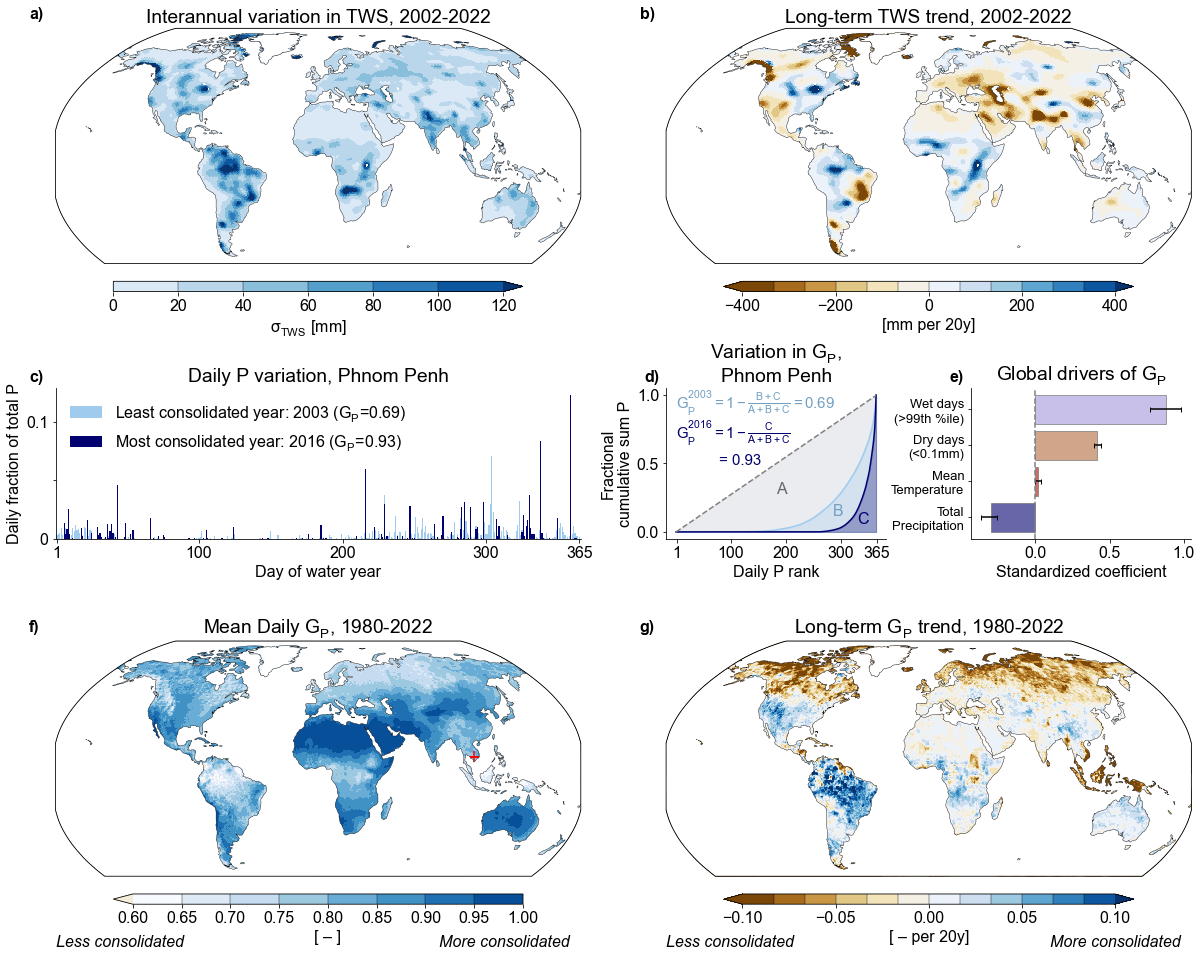

In [27]:

col_max = '#01016f'
col_min = '#9fcbee'

fig = plt.figure(figsize=(17,14))

axs = []
gs = GridSpec(10, 8)

axs.append(fig.add_subplot(gs[:4,:4],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[:4,4:],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[4:6,:4]))
axs.append(fig.add_subplot(gs[4:6,4:6]))
axs.append(fig.add_subplot(gs[4:6,6:]))
axs.append(fig.add_subplot(gs[6:,:4],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[6:,4:],projection=ccrs.Robinson()))

### a) TWS SD
ax = axs[0]
vmin = 0
vmax = 120
cmaph,normh = hydro_cmap(vmin,vmax)
lab = r'$\sigma_{TWS}$ [mm]'

grace_sd.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.78,
                                                      'aspect':40,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.set_title('Interannual variation in TWS, 2002-2022')
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')


### b) TWS trend
ax = axs[1]
vmin = -400
vmax = 400
cmaph,normh = delta_cmap(vmin,vmax)
lab = r'[mm per 20y]'

grace_trend.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.78,
                                                      'aspect':40,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})
ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.set_title('Long-term TWS trend, 2002-2022')


#### c) interannual P variation at phnom penh: 105.25,12.25
ax = axs[2]
gpsub = pr_gini_wy.sel(lon=105.25,lat=12.25)
maxyr = gpsub.water_year[gpsub.argmax(dim='water_year').Pgini_wy].values
minyr = gpsub.water_year[gpsub.argmin(dim='water_year').Pgini_wy].values
maxgp =  gpsub.Pgini_wy[gpsub.argmax(dim='water_year').Pgini_wy]
mingp =  gpsub.Pgini_wy[gpsub.argmin(dim='water_year').Pgini_wy]
cpcsub = cpc.sel(lon=105.25,lat=12.25)
minp = cpcsub.sel(time=slice(f'{minyr}-10-01', f'{minyr+1}-09-30')).precip.to_series().values
maxp = cpcsub.sel(time=slice(f'{maxyr}-10-01', f'{maxyr+1}-09-30')).precip.to_series().values

x = np.arange(len(minp))

b1=ax.bar(x,minp/np.nansum(minp),color=col_min)
b2=ax.bar(x[:-1],maxp/maxp.sum(),color=col_max)
ax.set_xlim(0,366)
ax.set_xticks([1,100,200,300,365])
ax.legend([b1,b2],[r'Least consolidated year: ' + str(minyr) + ' ($G_P$='+str(mingp.values.round(2))+')',
                   r'Most consolidated year: ' + str(maxyr) + ' ($G_P$='+str(maxgp.values.round(2))+')'],
         fontsize=16,frameon=False)
ax.set_ylabel('Daily fraction of total P')
ax.set_xlabel('Day of water year')

ax.set_yticks([0,0.05,0.1])
ax.set_yticklabels(['0','','0.1'])
ax.set_title(r'Daily P variation, Phnom Penh')
           

#### d) lorenz curves -- Gp calculation schematic
ax = axs[3]

#need to sort the p time series for lorenz curves  
minp.sort()
maxp.sort()

ax.plot(np.cumsum(minp)/np.nansum(minp),color=col_min)
ax.plot(np.cumsum(maxp)/np.nansum(maxp),color=col_max)
ax.plot(np.arange(0,1,1/365),linestyle='--',color='grey')

ax.fill_between(np.arange(0,365),np.repeat(0,len(np.arange(0,1,1/365))),np.arange(0,1,1/365),color='#c0c2cf',alpha=0.3)
ax.fill_between(np.arange(0,len(minp)),np.repeat(0,len(minp)),np.cumsum(minp)/np.nansum(minp),color=col_min,alpha=0.3)
ax.fill_between(np.arange(0,len(maxp)),np.repeat(0,len(maxp)),np.cumsum(maxp)/np.nansum(maxp),color=col_max,alpha=0.3)
#ax.fill_between(np.arange(0,len(maxp)),(np.cumsum(minp)/np.nansum(minp))[:-1],np.cumsum(maxp)/np.nansum(maxp),
#                color=None,alpha=0.3,hatch='//',edgecolor=col_max)

ax.text(0.5,0.3,'A',transform=ax.transAxes,color='dimgrey')
ax.text(0.76,0.15,'B',transform=ax.transAxes,color='#729fc2')
ax.text(0.87,0.1,'C',transform=ax.transAxes,color=col_max)
ax.text(0.08,0.9,r'$G_P^{2003} = 1-\frac{B+C}{A+B+C} = 0.69$',color='#729fc2',fontsize=15)
ax.text(0.08,0.68,r'$G_P^{2016} = 1-\frac{C}{A+B+C}$',color=col_max,fontsize=15)
ax.text(78,0.49,'= 0.93',color=col_max,fontsize=15)

ax.set_ylabel('Fractional\ncumulative sum P')
ax.set_xlabel('Daily P rank')
ax.set_xticks([1,100,200,300,365])
ax.set_title(r'Variation in $G_P$,'+'\nPhnom Penh')


#### e) drivers of Gp
ax = axs[4]
col_p = '#01016f'
col_t = '#AE0C00'
col_dd = '#b36a3b'
col_wd = '#a496d9'

cols = [col_p,col_t,col_dd,col_wd]
labs = ['Total\nPrecipitation','Mean\nTemperature','Dry days\n(<0.1mm)','Wet days\n(>99th %ile)']

ax.barh(np.arange(4),[P_mean,T_mean,WD_mean,DD_mean],color=cols,alpha=0.6,
       xerr=ses,capsize=2.5,edgecolor='dimgrey',
       error_kw={'ecolor': 'black', 'elinewidth': 1.5})

ax.axvline(0,linestyle='--',color='grey')
ax.set_yticks(np.arange(4))
ax.set_yticklabels(labs,fontsize=13)
ax.set_xlabel(r'Standardized coefficient')
ax.set_title(r'Global drivers of $G_P$')

### f) mean Gp
ax = axs[5]
vmin = 0.6
vmax = 1
cmaph,normh = hydro_cmap(vmin,vmax,ncol=15)
lab = r'[ – ]'

gpmean.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.78,
                                                      'aspect':40,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})
ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
ax.set_title(r'Mean Daily $G_P$, 1980-2022')

ax.text(0,-0.3,'Less consolidated',style='italic',transform=ax.transAxes)
ax.text(0.73,-0.3,'More consolidated',style='italic',transform=ax.transAxes)

ax.scatter(105.25,11.75,c='red',marker='+',s=150,transform=ccrs.PlateCarree())

# g) Gp trend/change
ax = axs[6]
vmin = -0.1
vmax = 0.1
cmaph,normh = delta_cmap(vmin,vmax)
lab = r'[ – per 20y]'

dGp_mean.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.78,
                                                      'aspect':40,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')

ax.set_title(r'Long-term $G_P$ trend, 1980-2022')

ax.text(0,-0.3,'Less consolidated',style='italic',transform=ax.transAxes)
ax.text(0.73,-0.3,'More consolidated',style='italic',transform=ax.transAxes)

#lettering and ax adjustments

lets = 'abcdefghi'
for i,ax in enumerate(axs):
    ax.spines[['right', 'top']].set_visible(False)
    if i not in [3,4]:
        ax.text(-0.05,1.04,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    else:
        ax.text(-0.1,1.04,lets[i]+')',transform=ax.transAxes,fontweight='bold')

fig.canvas.draw()
plt.tight_layout(w_pad=0.08,h_pad=0.1)

#plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/clean/Fig.1.pdf',bbox_inches='tight')

key numbers reported:

### Fig 2. main regression results: TWS GP

In [34]:
# load absolute regression coefficients
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_regression_results.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_regression_results.csv')

In [49]:
###  calculate conditional marginal effect +/- SE
scale = 0.1 # per 0.1 gp
scale = scale*cm_to_mm
n_se = 2

#conditional coef estimates
gamma_abs = cpc_results['coef_Gp'][0]
chi_abs = cpc_results['coef_GpP'][0]
gamma_se = cpc_results['se_Gp'][0]
chi_se = cpc_results['se_GpP'][0]
cov_gamma_chi = cpc_results['vcov'][0]

#same coefs for GPCP data
gamma_gpcp_abs = gpcp_results['coef_Gp'][0]
chi_gpcp_abs = gpcp_results['coef_GpP'][0]
gamma_gpcp_se = gpcp_results['se_Gp'][0]
chi_gpcp_se = gpcp_results['se_GpP'][0]
cov_gpcp_gamma_chi = gpcp_results['vcov'][0]

# same for GPCC
gamma_gpcc_abs = gpcc_results['coef_Gp'][0]
chi_gpcc_abs = gpcc_results['coef_GpP'][0]
gamma_gpcc_se = gpcc_results['se_Gp'][0]
chi_gpcc_se = gpcc_results['se_GpP'][0]
cov_gpcc_gamma_chi = gpcc_results['vcov'][0]

# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x


In [55]:
# load standardized regression coefficients
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_std_regression_results.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_std_regression_results.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_std_regression_results.csv')

In [56]:
# standardized coefficients, 3 dataproducts
thetaS_CPC = [cpc_results['coef_T'][0],cpc_results['se_T'][0]]
piS_CPC = [cpc_results['coef_P'][0],cpc_results['se_P'][0]]
gammaS_CPC = [cpc_results['coef_Gp'][0],cpc_results['se_Gp'][0]]
chiS_CPC = [cpc_results['coef_GpP'][0],cpc_results['se_GpP'][0]]
cov_CPC = cpc_results['vcov'][0]

thetaS_GPCP = [gpcp_results['coef_T'][0],gpcp_results['se_T'][0]]
piS_GPCP = [gpcp_results['coef_P'][0],gpcp_results['se_P'][0]]
gammaS_GPCP = [gpcp_results['coef_Gp'][0],gpcp_results['se_Gp'][0]]
chiS_GPCP = [gpcp_results['coef_GpP'][0],gpcp_results['se_GpP'][0]]
cov_GPCP = gpcp_results['vcov'][0]

thetaS_GPCC = [gpcc_results['coef_T'][0],gpcc_results['se_T'][0]]
piS_GPCC = [gpcc_results['coef_P'][0],gpcc_results['se_P'][0]]
gammaS_GPCC = [gpcc_results['coef_Gp'][0],gpcc_results['se_Gp'][0]]
chiS_GPCC = [gpcc_results['coef_GpP'][0],gpcc_results['se_GpP'][0]]
cov_GPCC = gpcc_results['vcov'][0]

psample = 1000
dt_CPC = gammaS_CPC[0] + chiS_CPC[0]*psample
dtse_CPC = np.sqrt(gammaS_CPC[1]**2 + (psample**2) * chiS_CPC[1]**2 + 2 * psample * cov_CPC)
dt_GPCP = gammaS_GPCP[0] + chiS_GPCP[0]*psample
dtse_GPCP = np.sqrt(gammaS_GPCP[1]**2 + (psample**2) * chiS_GPCP[1]**2 + 2 * psample * cov_GPCP)
dt_GPCC = gammaS_GPCC[0] + chiS_GPCC[0]*psample
dtse_GPCC = np.sqrt(gammaS_GPCC[1]**2 + (psample**2) * chiS_GPCC[1]**2 + 2 * psample * cov_GPCC)
                   


In [50]:
### setup multi-obs mean at basin level 
dset = ['CPC','GPCC','GPCP']
dset_suffix = ['','_GPCC','_GPCP']

#merge all dataset results
mergedall = {}
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')
grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})

basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[0]+'.csv')
mergedall = grdc_basins.merge(basin_models[['basin_id','coef_Gp','pval_Gp']], on='basin_id', how='outer')

basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[1]+'.csv')
basin_models = basin_models.rename(columns={'coef_Gp':'coef_Gp'+dset_suffix[1],'pval_Gp':'pval_Gp'+dset_suffix[1]})
mergedall = mergedall.merge(basin_models[['basin_id','coef_Gp'+dset_suffix[1],'pval_Gp'+dset_suffix[1]]], on='basin_id', how='outer')

basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[2]+'.csv')
basin_models = basin_models.rename(columns={'coef_Gp':'coef_Gp'+dset_suffix[2],'pval_Gp':'pval_Gp'+dset_suffix[2]})
mergedall = mergedall.merge(basin_models[['basin_id','coef_Gp'+dset_suffix[2],'pval_Gp'+dset_suffix[2]]], on='basin_id', how='outer')

#average Gp coefficients across datasets:
mergedall['coef_Gp_mean'] = mergedall[['coef_Gp','coef_Gp_GPCC','coef_Gp_GPCP']].mean(axis=1)



In [51]:
# multi-product significance criteria:
def check_sig_consistent(row):
    # only functional for 3 products 
    # returns True if at least 2/3 products significant and same sign:
    
    # get signs of the coefficients
    signs = [np.sign(row['coef_Gp']), np.sign(row['coef_Gp_GPCC']), np.sign(row['coef_Gp_GPCP'])]
    
    # check if significant
    significant = [row['pval_Gp'] < 0.05, row['pval_Gp_GPCC'] < 0.05, row['pval_Gp_GPCP'] < 0.05]
    
    # gather coefs if have the same sign and are significant
    significant_coefs = [sign for sign, sig in zip(signs, significant) if sig]
    
    # if 3 coefs significant, cannot have a tie with 3 dataproducts, therefore sig and consist:
    if len(significant_coefs) == 3:
        return 1
    # if 2 coefs sig, can have tie: check if not tie (sum not = 0)
    elif len(significant_coefs) == 2 and sum(significant_coefs) != 0:
        return 1
    #otherwise not sig and consistent
    else:
        return 0

# Apply the function to each row of the dataframe
mergedall['sig_consist'] = mergedall.apply(check_sig_consistent, axis=1)



In [52]:
row = mergedall[mergedall.RIVER_BASI=='CHAD']
# Check the signs of the coefficients
signs = [np.sign(row['coef_Gp']).values, np.sign(row['coef_Gp_GPCC']).values, np.sign(row['coef_Gp_GPCP']).values]

# Check if p-values are significant
significant = [row['pval_Gp'].values < 0.05, row['pval_Gp_GPCC'].values < 0.05, row['pval_Gp_GPCP'].values < 0.05]

# Count how many coefficients have the same sign and are significant
significant_coefs = [sign for sign, sig in zip(signs, significant) if sig]

    

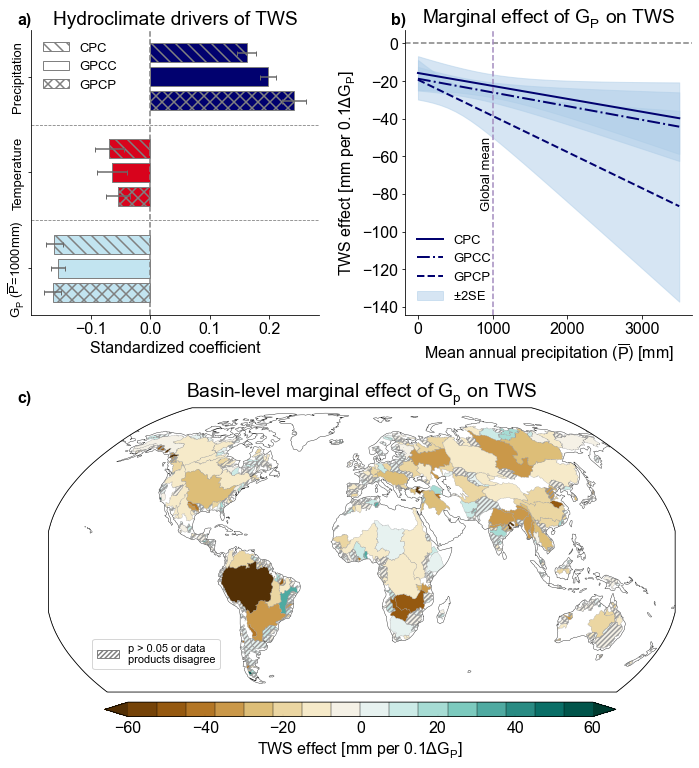

In [53]:
fig = plt.figure(figsize=(10,10))

axs = []
gs = GridSpec(2, 2)

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[0,1]))
axs.append(fig.add_subplot(gs[1,:],projection=ccrs.Robinson()))

col_p = '#01016f'
col_t = '#d8031c'
col_gp = '#c2e4f0'
col_gp1000 = '#aecde8'
col_gp2000 = '#9ac2ed'
col_gp3000 = '#7bb2ed'

##############
ax = axs[1]
# a) conditional gamma
#cpc
l1=ax.plot(x,y,color=col_p,linewidth=2)
s1 = ax.fill_between(x,effecthi,effectlo,color=col_gp1000,alpha=0.5)

#gpcp
l2=ax.plot(x,ygpcp,color=col_p,linewidth=2,linestyle='--')
s2 = ax.fill_between(x,effecthi_gpcp,effectlo_gpcp,color=col_gp1000,alpha=0.5)

#gpcc
l3=ax.plot(x,ygpcc,color=col_p,linewidth=2,linestyle='-.')
s3 = ax.fill_between(x,effecthi_gpcc,effectlo_gpcc,color=col_gp1000,alpha=0.5)

ax.axhline(0,linestyle='--',color='grey')
ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
ax.set_ylabel('TWS effect [mm per ' +r'$0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)
ax.set_title(r'Marginal effect of $G_P$ on TWS'  )

ax.axvline(1000,linestyle='--',color='#a38bbf')
ax.text(850,-87,'Global mean',fontsize=13,rotation=90)
#legend
lg=ax.legend([l1[0],l3[0],l2[0],s1],['CPC','GPCC','GPCP',r'$\pm$'+str(n_se) + 'SE'],
             loc='lower left',facecolor='white',edgecolor='white',fontsize=13)
lg.get_frame().set_alpha(0)

ax.spines[['right', 'top']].set_visible(False)

#######################
#b) standardized
ax = axs[0]

bars = [piS_CPC[0],piS_GPCC[0],piS_GPCP[0],
        thetaS_CPC[0],thetaS_GPCC[0],thetaS_GPCP[0],
        dt_CPC,dt_GPCC,dt_GPCP]

ses = [piS_CPC[1],piS_GPCC[1],piS_GPCP[1],
        thetaS_CPC[1],thetaS_GPCC[1],thetaS_GPCP[1],
        dtse_CPC,dtse_GPCC,dtse_GPCP]

bcols = [col_p,col_p,col_p,col_t,col_t,col_t,col_gp,col_gp,col_gp]
bhatchs = ['\\\\','','XX','\\\\','','XX','\\\\','','XX']

bx = [1,2,3,5,6,7,9,10,11]

ax.barh(bx,bars,color=bcols,xerr=ses,capsize=2.5,
       error_kw={'ecolor': 'dimgrey', 'elinewidth': 1.5})
h1 = ax.barh(bx,bars,facecolor='none',edgecolor='grey',hatch=bhatchs)
ax.axvline(0,linestyle='--',color='grey')
ax.axhline(4,linestyle='--',linewidth=0.8,color='grey')
ax.axhline(8,linestyle='--',linewidth=0.8,color='grey')

ax.set_yticks([2,6,10])
ax.set_yticklabels(['Precipitation','Temperature',r'$G_P$ ($\overline{P}$=1000mm)'],va='center',rotation=90,fontsize=13)
labels = ax.get_yticklabels()
labels[2].set_position((labels[2].get_position()[0]+0.01,labels[2].get_position()[1]))

ax.set_xlabel('Standardized coefficient')

ax.invert_yaxis()

ax.legend([h1[0],h1[1],h1[2]],['CPC','GPCC','GPCP'],frameon=False,fontsize=13)

ax.set_title('Hydroclimate drivers of TWS')

ax.spines[['right', 'top']].set_visible(False)

###############
ax = axs[2]
#select column to plot
plotdat = 'coef_Gp_mean'
sigdat = 'pval_Gp'


# set colors
vmin = -60
vmax = 60
ncol = 17 # choose a number greater than
         # the number of colors you actually want
bounds = np.linspace(vmin,vmax,ncol)
cmapname = 'BrBG'
cols = plt.get_cmap(cmapname)(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = colors.Normalize(vmin=vmin,vmax=vmax)
cbar = plt.cm.ScalarMappable(norm=norm,cmap=cmap)

# map
mergedall.plot(column=plotdat,transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, linewidth=0.2, ax=ax, edgecolor='0.6', legend=False)

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='0.1',facecolor=[1,1,1],linewidth=0.4) 

#hatch_polygons = mergedall[mergedall[sigdat] > 0.05]
hatch_polygons = mergedall[mergedall['sig_consist'] < 1]

hatch_polygons.plot(transform=ccrs.PlateCarree(),
    ax=ax, 
    facecolor="none",  # no fill color for hatching layer
    edgecolor='0.6',   # neep border color consistent
    hatch='/////',      # hatch pattern
    linewidth=0.2
)

b = ax.bar(-1,-1,facecolor='none',edgecolor='grey',hatch='/////')

ax.set_title(r'Basin-level marginal effect of $G_p$ on TWS')
cbar_ax = fig.add_axes([0.16,-0.01,0.71,0.02])
plt.setp(cbar_ax.spines.values(), linewidth=0.3)
#tks = [-2,-1,0,1,2]
cb = fig.colorbar(cbar,cax=cbar_ax,orientation="horizontal",
                          drawedges=True,extend="both")#,ticks=tks)
cbar_ax.tick_params(direction="in",width=0.05)
cb.set_label(label=r"TWS effect [mm per 0.1$\Delta G_P$]")

ax.legend([b],['p > 0.05 or data\nproducts disagree'],fontsize=11,loc=(0.07,0.08))
# lettering
lets = 'abcdefghi'

for i,ax in enumerate(axs):
    ax.text(-0.05,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
fig.canvas.draw()
plt.tight_layout()

#plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/clean/Fig.2.pdf',bbox_inches='tight')

Key numbers reported (Fig 2)

In [63]:
# note GP effect is almost as large as P effect
print('Gp effect / P effect, standardized, CPC: ' + str(dt_CPC/piS_CPC[0]))
print('Gp effect / P effect, standardized, GPCC: ' + str(dt_GPCC/piS_GPCC[0]))
print('Gp effect / P effect, standardized, GPCP: ' + str(dt_GPCP/piS_GPCP[0]))

Gp effect / P effect, standardized, CPC: -0.9938271604938271
Gp effect / P effect, standardized, GPCC: -0.7860918987641068
Gp effect / P effect, standardized, GPCP: -0.6799405980494418


In [110]:
# comparing precip to Gp effect (standardized, Gp at MAP = 1000mm/yr)
precip_effect_range = [min([piS_CPC[0],piS_GPCC[0],piS_GPCP[0]]),max([piS_CPC[0],piS_GPCC[0],piS_GPCP[0]])]
Gp_effect_range = [min([dt_CPC,dt_GPCC,dt_GPCP]),max([dt_CPC,dt_GPCC,dt_GPCP])]
print('range: precip | Gp')
print(precip_effect_range,Gp_effect_range)

print('mean precip:')
print(np.mean([piS_CPC[0],piS_GPCC[0],piS_GPCP[0]]))

print('mean Gp:')
print(np.mean([dt_CPC,dt_GPCC,dt_GPCP]))

print('mean temp effect:')
print(np.mean([thetaS_CPC[0],thetaS_GPCC[0],thetaS_GPCP[0]]))

range: precip | Gp
[0.162, 0.2409868804711] [-0.1638567636295891, -0.1552961159439559]
mean precip:
0.20018051270795534
mean Gp:
-0.16005095985784834
mean temp effect:
-0.0625163085874408


In [111]:
# 95% CI effect at global mean MAP
mineffect = min(effectlo[x==1000],effectlo_gpcp[x==1000],effectlo_gpcc[x==1000])
maxeffect = max(effecthi[x==1000],effecthi_gpcp[x==1000],effecthi_gpcc[x==1000])
print(mineffect,maxeffect)

[-49.01551861] [-16.29808965]


In [112]:
# 95% CI effect in deserts
mineffect = min(effectlo[x==200],effectlo_gpcp[x==200],effectlo_gpcc[x==200])
maxeffect = max(effecthi[x==200],effecthi_gpcp[x==200],effecthi_gpcc[x==200])
print(mineffect,maxeffect)

[-31.52231718] [-9.31695104]


In [113]:
# 95% CI effect at global mean MAP
mineffect = min(effectlo[x==2900],effectlo_gpcp[x==2900],effectlo_gpcc[x==2900])
maxeffect = max(effecthi[x==2900],effecthi_gpcp[x==2900],effecthi_gpcc[x==2900])
print(mineffect,maxeffect)

[-113.59207302] [-18.10820643]


In [104]:
# basin scale numbers
print('fraction of area significant:')
print(merged[merged.pval_Gp<0.05].AREA_CALC.sum()/merged.AREA_CALC.sum())

print('fraction of area significant negative:')
frac_signeg = merged[(merged.pval_Gp<0.05) & (merged.coef_Gp<0)].AREA_CALC.sum()/merged.AREA_CALC.sum()
print(frac_signeg)

print('fraction of area significant positive:')
frac_sigpos = merged[(merged.pval_Gp<0.05) & (merged.coef_Gp>0)].AREA_CALC.sum()/merged.AREA_CALC.sum()
print(frac_sigpos)

print('fraction of significant area that is negative:')
merged[(merged.pval_Gp<0.05) & (merged.coef_Gp<0)].AREA_CALC.sum()/merged[(merged.pval_Gp<0.05)].AREA_CALC.sum()

fraction of area significant:
0.8352581232784818
fraction of area significant negative:
0.666581536983339
fraction of area significant positive:
0.16867658629514287
fraction of significant area that is negative:


0.798054539555906

### Fig. 3 mechanism

In [64]:
# function to compute 95% estimation CI of fit
def intSE(y,se_Gp,se_GpP,cov,scale=1,n_se=2):
    variance = se_Gp**2 + (x**2) * se_GpP**2 + 2*x * cov
    se = np.sqrt(variance)
    effecthi = y+scale*n_se*se
    effectlo = y-scale*n_se*se
    return effectlo,effecthi


In [70]:
# SW dependence on Gp for panel A
scale = 0.1 # not 1, because not scaling mm to cm, only adjusting per 0.1 Gp

sw_gp_results = pd.read_csv(save_dir+'reg_results/SW_Gp_regression_results.csv')

sg_cpc = scale*(sw_gp_results.coef_Gp_CPC[0]+sw_gp_results.coef_GpP_CPC[0]*x)
sg_gpcp = scale*(sw_gp_results.coef_Gp_GPCP[0]+sw_gp_results.coef_GpP_GPCP[0]*x)
sg_gpcc = scale*(sw_gp_results.coef_Gp_GPCC[0]+sw_gp_results.coef_GpP_GPCC[0]*x)

sglo_cpc, sghi_cpc = intSE(sg_cpc,sw_gp_results.se_Gp_CPC[0],sw_gp_results.se_GpP_CPC[0],sw_gp_results.cov_CPC[0],scale=scale)
sglo_gpcp, sghi_gpcp = intSE(sg_gpcp,sw_gp_results.se_Gp_GPCP[0],sw_gp_results.se_GpP_GPCP[0],sw_gp_results.cov_GPCP[0],scale=scale)
sglo_gpcc, sghi_gpcc = intSE(sg_gpcc,sw_gp_results.se_Gp_GPCC[0],sw_gp_results.se_GpP_GPCC[0],sw_gp_results.cov_GPCC[0],scale=scale)



In [65]:
# load SW regression results (and main model results, for comparison)
cpc_results_SW = pd.read_csv(save_dir+'reg_results/CPC_regression_results_SWint.csv')
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')

gpcp_results_SW = pd.read_csv(save_dir+'reg_results/GPCP_regression_results_SWint.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_regression_results.csv')

gpcc_results_SW = pd.read_csv(save_dir+'reg_results/GPCC_regression_results_SWint.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_regression_results.csv')

In [66]:
# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)

# for panel B, distribution effect (w SW control) and full effect (no SW control)
ysw_cpc = scale*cpc_results_SW.coef_Gp[0]+scale*cpc_results_SW.coef_GpP[0]*x
y_cpc = scale*cpc_results.coef_Gp[0]+scale*cpc_results.coef_GpP[0]*x

ysw_gpcc = scale*gpcc_results_SW.coef_Gp[0]+scale*gpcc_results_SW.coef_GpP[0]*x
y_gpcc = scale*gpcc_results.coef_Gp[0]+scale*gpcc_results.coef_GpP[0]*x

ysw_gpcp = scale*gpcp_results_SW.coef_Gp[0]+scale*gpcp_results_SW.coef_GpP[0]*x
y_gpcp = scale*gpcp_results.coef_Gp[0]+scale*gpcp_results.coef_GpP[0]*x

#uncertainty distribution effect:
effectlosw_cpc, effecthisw_cpc = intSE(ysw_cpc,cpc_results_SW.se_Gp[0],cpc_results_SW.se_GpP[0],cpc_results_SW.vcov[0])
effectlosw_gpcp, effecthisw_gpcp = intSE(ysw_gpcp,gpcp_results_SW.se_Gp[0],gpcp_results_SW.se_GpP[0],gpcp_results_SW.vcov[0])
effectlosw_gpcc, effecthisw_gpcc = intSE(ysw_gpcc,gpcc_results_SW.se_Gp[0],gpcc_results_SW.se_GpP[0],gpcc_results_SW.vcov[0])

#uncertainty full effect:
effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])
effectlo_gpcp, effecthi_gpcp = intSE(y_gpcp,gpcp_results.se_Gp[0],gpcp_results.se_GpP[0],gpcp_results.vcov[0])
effectlo_gpcc, effecthi_gpcc = intSE(y_gpcc,gpcc_results.se_Gp[0],gpcc_results.se_GpP[0],gpcc_results.vcov[0])


In [67]:
# to simplify visualization, average the SW control fits for the three datasets:
ymean = np.mean(np.array([y_cpc,y_gpcp,y_gpcc]),axis=0)
ymean_sw = np.mean(np.array([ysw_cpc,ysw_gpcp,ysw_gpcc]),axis=0)

# and take the min and max of the SW CI's
yswmin = np.min(np.array([effectlosw_cpc,effectlosw_gpcp,effectlosw_gpcc]),axis=0)
yswmax = np.max(np.array([effecthisw_cpc,effecthisw_gpcp,effecthisw_gpcc]),axis=0)

# main model uncertainty:
ymin = np.min(np.array([effectlo_cpc,effectlo_gpcp,effectlo_gpcc]),axis=0)
ymax = np.max(np.array([effecthi_cpc,effecthi_gpcp,effecthi_gpcc]),axis=0)

# For panel C, now estimate distribution effect as fit controllong for SW over fit without control, for each product, then averaged:
fracdist = np.mean([ysw_cpc/y_cpc,ysw_gpcp/y_gpcp,ysw_gpcc/y_gpcc],axis=0)*100
fdmax = 100*yswmax/ymax
fdmin = 100*yswmin/ymin

# and individually
fracdist_cpc = ysw_cpc/y_cpc*100
fracdist_gpcp = ysw_gpcp/y_gpcp*100
fracdist_gpcc = ysw_gpcc/y_gpcc*100

# finally, get the interval between these curves for different products
fracmin = np.min(np.array([[fracdist_cpc],[fracdist_gpcc],[fracdist_gpcp]]),axis=0).flatten()
fracmax = np.max(np.array([[fracdist_cpc],[fracdist_gpcc],[fracdist_gpcp]]),axis=0).flatten()


In [68]:
# for panel D, load ET results and compute conditional dependence
# unit to scale Gp sensitivity to (per 0.1 Gp)
scale = 0.1 # here not converting cm to mm because ET data is in mm, while TWS is in cm
n_se = 2

### et coefficients
et_results = pd.read_csv(save_dir+'/reg_results/ET_regression_results.csv')

#conditional coef estimates
gamma_se = et_results.se_Gp_CPC[0]
chi_se = et_results.se_GpP_CPC[0]
gamma_abs = et_results.coef_Gp_CPC[0]
chi_abs = et_results.coef_GpP_CPC[0]
cov_gamma_chi = et_results.vcov_CPC[0]

gamma_se_GPCC = et_results.se_Gp_GPCC[0]
chi_se_GPCC = et_results.se_GpP_GPCC[0]
gamma_abs_GPCC = et_results.coef_Gp_GPCC[0]
chi_abs_GPCC = et_results.coef_GpP_GPCC[0]
cov_gamma_chi_GPCC = et_results.vcov_GPCC[0]

gamma_se_GPCP = et_results.se_Gp_GPCP[0]
chi_se_GPCP = et_results.se_GpP_GPCP[0]
gamma_abs_GPCP = et_results.coef_Gp_GPCP[0]
chi_abs_GPCP = et_results.coef_GpP_GPCP[0]
cov_gamma_chi_GPCP = et_results.vcov_GPCP[0]

# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
yet_cpc = scale*gamma_abs+scale*chi_abs*x
yet_gpcc = scale*gamma_abs_GPCC+scale*chi_abs_GPCC*x
yet_gpcp = scale*gamma_abs_GPCP+scale*chi_abs_GPCP*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthiET_CPC = yet_cpc+scale*n_se*se
effectloET_CPC = yet_cpc-scale*n_se*se

variance = gamma_se_GPCC**2 + (x**2) * chi_se_GPCC**2 + 2 * x * cov_gamma_chi_GPCC
se = np.sqrt(variance)
effecthiET_GPCC = yet_gpcc+scale*n_se*se
effectloET_GPCC = yet_gpcc-scale*n_se*se

variance = gamma_se_GPCP**2 + (x**2) * chi_se_GPCP**2 + 2 * x * cov_gamma_chi_GPCP
se = np.sqrt(variance)
effecthiET_GPCP = yet_gpcp+scale*n_se*se
effectloET_GPCP = yet_gpcp-scale*n_se*se


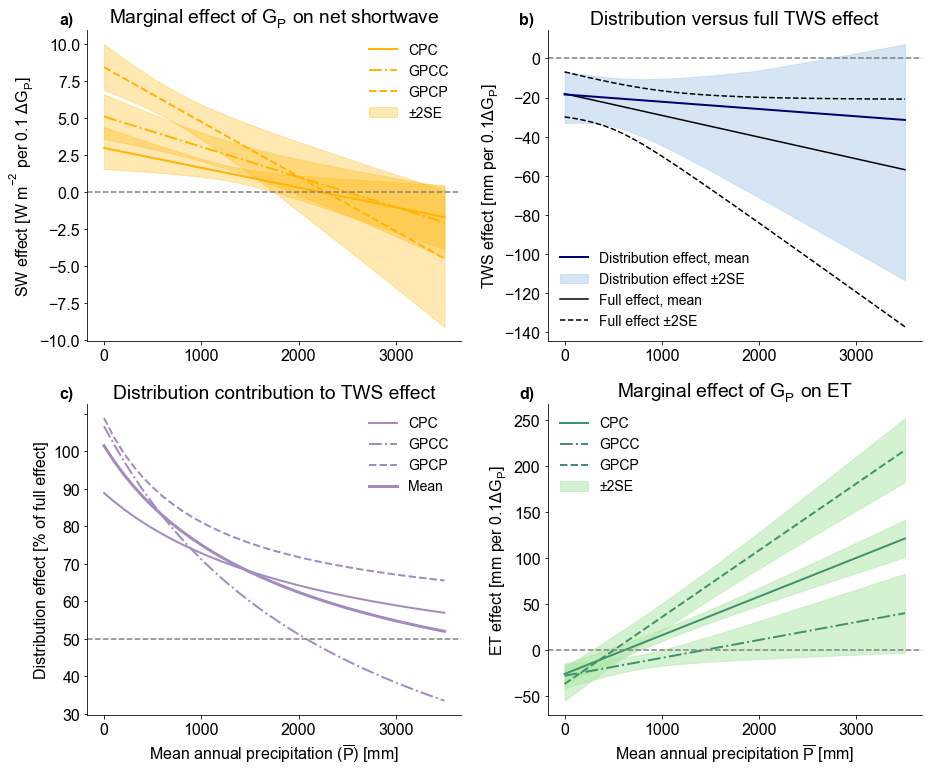

In [71]:
fsizel = 14
lets = 'abcd'

fig = plt.figure(figsize=(13,11))

axs = []
gs = GridSpec(2, 2)

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[0,1]))
axs.append(fig.add_subplot(gs[1,0]))
axs.append(fig.add_subplot(gs[1,1]))

ax = axs[0]
color = '#ffb501'#'#FFBF00'
l0 = ax.plot(x,sg_cpc,color=color,linewidth=2)
l1 = ax.plot(x,sg_gpcc,color=color,linewidth=2,linestyle='-.')
l2 = ax.plot(x,sg_gpcp,color=color,linewidth=2,linestyle='--')
s0 = ax.fill_between(x,sglo_cpc,sghi_cpc,color=color,alpha=0.3)
ax.fill_between(x,sglo_gpcc,sghi_gpcc,color=color,alpha=0.3)
ax.fill_between(x,sglo_gpcp,sghi_gpcp,color=color,alpha=0.3)
ax.set_ylabel('SW effect [W $m^{-2}$ per 0.1 $\Delta G_P$]')
ax.set_title('Marginal effect of $G_P$ on net shortwave')
ax.legend([l0[0],l1[0],l2[0],s0],['CPC','GPCC','GPCP','±2SE'],fontsize=fsizel,frameon=False)

ax.axhline(0,linestyle='--',color='grey')

# b) Total vs Distribution effect TWS
ax = axs[1]
color='cadetblue'

l0=ax.plot(x,ymean,'k-')
l1=ax.plot(x,ymin,'k--')
ax.plot(x,ymax,'k--')

l2=ax.plot(x,ymean_sw,color='#01016f',linewidth=2)
f0=ax.fill_between(x,yswmin,yswmax,color='#aecde8',alpha=0.5)
ax.axhline(0,linestyle='--',color='grey')
ax.set_ylabel('TWS effect [mm per $0.1 \Delta G_P$]')

ax.legend([l2[0],f0,l0[0],l1[0]],['Distribution effect, mean',
                                  'Distribution effect ±2SE',
                                  'Full effect, mean',
                                  'Full effect ±2SE'],
          fontsize=fsizel,frameon=False)

ax.set_title('Distribution versus full TWS effect')


# c) partitioning distributional effect:

ax = axs[2]
color='#a38bbf'
qshade_col = '#bdacd1'
qline_col = '#a38bbf'
l0=ax.plot(x,fracdist,color=color,linewidth=3)
l1=ax.plot(x,fracdist_cpc,color=color,linewidth=2)
l2=ax.plot(x,fracdist_gpcc,color=color,linestyle='-.',linewidth=2)
l3=ax.plot(x,fracdist_gpcp,color=color,linestyle='--',linewidth=2)
#ax.fill_between(x,fracmin,fracmax,color=color,alpha=0.1)
ax.legend([l1[0],l2[0],l3[0],l0[0]],['CPC','GPCC','GPCP','Mean'],fontsize=fsizel,frameon=False)

ax.axhline(50,linestyle='--',color='grey')
ytlabs = list(np.arange(30,101,10).astype('str'))
ytlabs.append('')
ax.set_yticklabels(['']+ytlabs)
ax.set_ylabel('Distribution effect [% of full effect]')
ax.set_title('Distribution contribution to TWS effect')
ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')


# d) ET effects, across P products
ax = axs[3]

etshade_col = '#abe7a4'#'#74c69d'
etline_col = '#40916c'


l1=ax.plot(x,yet_cpc,color=etline_col,linewidth=2)
l2=ax.plot(x,yet_gpcc,color=etline_col,linewidth=2,linestyle='-.')
l3=ax.plot(x,yet_gpcp,color=etline_col,linewidth=2,linestyle='--')

s1 = ax.fill_between(x,effectloET_CPC,effecthiET_CPC,color=etshade_col,alpha=0.5)
ax.fill_between(x,effectloET_GPCC,effecthiET_GPCC,color=etshade_col,alpha=0.5)
ax.fill_between(x,effectloET_GPCP,effecthiET_GPCP,color=etshade_col,alpha=0.5)

ax.axhline(0,linestyle='--',color='grey')
ax.set_xlabel('Mean annual precipitation '+r'$\overline{P}$ [mm]')
ax.set_ylabel('ET effect [mm per ' +r'$0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)
ax.set_title(r'Marginal effect of $G_P$ on ET'  )

#l3 = ax.plot([],[],color='black',linewidth=3)
#l4 = ax.plot([],[],color='black',linewidth=3,linestyle='--')

#legend
ax.legend([l1[0],l2[0],l3[0],s1],['CPC','GPCC','GPCP','±2SE'],fontsize=fsizel,frameon=False)

# axis adjustments
for i,ax in enumerate(axs):
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(-0.075,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    

plt.tight_layout()
#plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/clean/Fig.3.pdf',bbox_inches='tight')

### Fig 4: SEMBH simulation results

In [72]:
#load median parameter runs
rsdf = pd.read_csv(save_dir + 'semhb_model_runs.csv')


In [81]:
prange = np.arange(0,3300,200)

# adjust to effect per 0.1 delta Gp, linearly
dTWSc = rsdf.dTWS*0.1/rsdf.dGp
rsdf['dTWSc'] = dTWSc
# where dGp is 0 - drop
rsdf = rsdf.dropna()
# where dGp is very small, adjusted dTWS can blow up -- not common, but can influence regression
rsdf = rsdf[(rsdf['dTWSc'] <= 1000) & (rsdf['dTWSc'] >= -1000)]

# adjust water budget term effects, too
rsdf['dETlakec'] = rsdf.dETlake*0.1/rsdf.dGp
rsdf['dETlandc'] = rsdf.dETland*0.1/rsdf.dGp
rsdf['dQoutc'] = rsdf.dQout*0.1/rsdf.dGp
rsdf['dQinc'] = rsdf.dQ*0.1/rsdf.dGp

# compute modeled relationship between ET and Gp
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(rsdf.pmean, rsdf.dTWSc)

# compute CI of model dTWSc/dGp
X = sm.add_constant(rsdf['pmean'].values)
ols_model = sm.OLS(rsdf['dTWSc'].values, X)
est = ols_model.fit()
pred = est.get_prediction(sm.add_constant(prange)).summary_frame()

# line and range
line = slope*prange+intercept

lower = pred['mean_ci_lower']
upper = pred['mean_ci_upper']




In [82]:
###  calculate conditional marginal effect +/- SE
scale = 0.1 # per 0.1 gp
scale = scale*cm_to_mm
n_se = 2

#conditional coef estimates
gamma_abs = cpc_results['coef_Gp'][0]
chi_abs = cpc_results['coef_GpP'][0]
gamma_se = cpc_results['se_Gp'][0]
chi_se = cpc_results['se_GpP'][0]
cov_gamma_chi = cpc_results['vcov'][0]

#same coefs for GPCP data
gamma_gpcp_abs = gpcp_results['coef_Gp'][0]
chi_gpcp_abs = gpcp_results['coef_GpP'][0]
gamma_gpcp_se = gpcp_results['se_Gp'][0]
chi_gpcp_se = gpcp_results['se_GpP'][0]
cov_gpcp_gamma_chi = gpcp_results['vcov'][0]

# same for GPCC
gamma_gpcc_abs = gpcc_results['coef_Gp'][0]
chi_gpcc_abs = gpcc_results['coef_GpP'][0]
gamma_gpcc_se = gpcc_results['se_Gp'][0]
chi_gpcc_se = gpcc_results['se_GpP'][0]
cov_gpcc_gamma_chi = gpcc_results['vcov'][0]

# range of mean P to sample conditional effect over:

y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#average of 3 pr obs 
empirical = np.mean(np.array([y,ygpcp,ygpcc]),axis=0)

In [83]:
#compute water budget terms means, binned over mean P
dETld = rsdf.groupby('Key').dETlandc.mean()
dETlk = rsdf.groupby('Key').dETlakec.mean()
dET = dETld + dETlk
dQ = rsdf.groupby('Key').dQoutc.mean()
dQin = rsdf.groupby('Key').dQinc.mean()


In [87]:
# load perturbed parameter experiment results
rsdfppe = pd.read_csv(save_dir+'SEMBH_model_runs_PPE.csv')
# adjust to effect per 0.1 delta Gp, linearly
dTWSc_ppe = rsdfppe.dTWS*0.1/rsdfppe.dGp
rsdfppe['dTWSc'] = dTWSc_ppe
rsdfppe = rsdfppe.dropna()
rsdfppe = rsdfppe[(rsdfppe['dTWSc'] <= 1000) & (rsdfppe['dTWSc'] >= -1000)]

rsdfppe['dETlakec'] = rsdfppe.dETlake*0.1/rsdfppe.dGp
rsdfppe['dETlandc'] = rsdfppe.dETland*0.1/rsdfppe.dGp
rsdfppe['dQoutc'] = rsdfppe.dQout*0.1/rsdfppe.dGp
rsdfppe['dQinc'] = rsdfppe.dQ*0.1/rsdfppe.dGp

# load parameter sets
pspace = pd.read_csv(save_dir+'SEMBH_parameter_sets.csv')



In [88]:
# compute modeled relationship between TWSc and Gp for each param set
lines = {}
slopes = {}

sdf = pd.DataFrame(columns=['param_set','slope','intercept','pvalue','se'])

for p in pspace.index:
    
    rdfsub = rsdfppe[rsdfppe.paramset == p]
    slope, intercept, r_value, p_value, std_err = linregress(rdfsub.pmean, rdfsub.dTWSc)
    sdf.loc[p] = [p,slope,intercept,p_value,std_err]
    
    # compute CI of model dTWSc/dGp
    X = sm.add_constant(rdfsub['pmean'].values)
    ols_model = sm.OLS(rdfsub['dTWSc'].values, X)
    est = ols_model.fit()
    pred = est.get_prediction(sm.add_constant(prange)).summary_frame()

    # line and range
    slopes[str(p)] = slope
    lines[str(p)] = slope*prange+intercept

    lower_ppe = pred['mean_ci_lower']
    upper_ppe = pred['mean_ci_upper']

# gather all TWS effect fits across all parameter runs (we'll plot percentiles of them)
stacked = np.stack(list(lines.values()), axis=0)


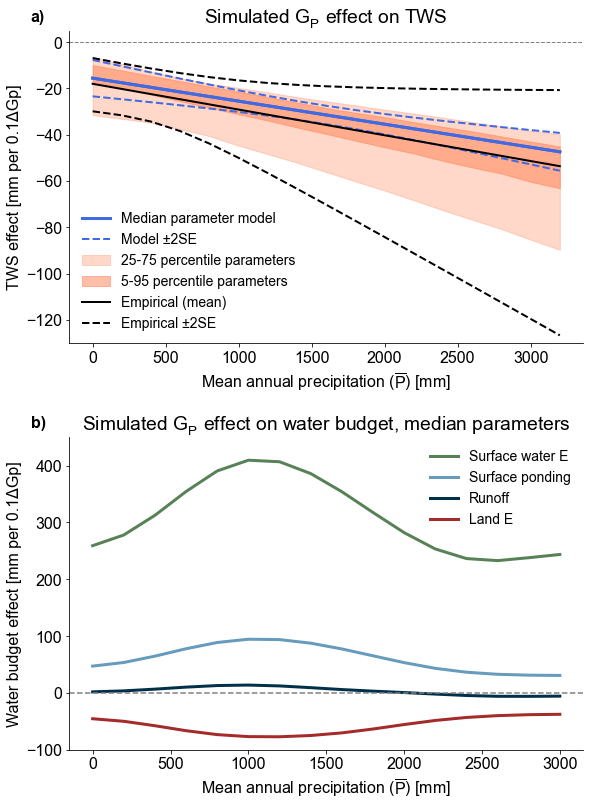

In [91]:
fig = plt.figure(figsize=(8,11))

axs = []
gs = GridSpec(2, 1)

lfsize = 14

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[1,0]))

### a) TWS effect, median params
ax = axs[0]

#model model
l0 = ax.plot(prange, line,linewidth=3,color='royalblue')
l1 = ax.plot(prange,lower,color='royalblue',linestyle='--',linewidth=2)
ax.plot(prange,upper,color='royalblue',linestyle='--',linewidth=2)

#empirical model
l2 = ax.plot(prange,empirical,color='black',linewidth=2)
l3 = ax.plot(prange,effecthi,color='black',linestyle='--',linewidth=2)
ax.plot(prange,effectlo_gpcp,color='black',linestyle='--',linewidth=2)

# Compute the 5th and 95th percentiles along the columns (axis=0)
pln_5 = np.percentile(stacked, 5, axis=0)
pln_95 = np.percentile(stacked, 95, axis=0)
pln_25 = np.percentile(stacked, 25, axis=0)
pln_75 = np.percentile(stacked, 75, axis=0)

l0 = ax.plot(prange, line,linewidth=3,color='royalblue')
f0 = ax.fill_between(prange,pln_5,pln_95,color='coral',alpha=0.3)
f1 = ax.fill_between(prange,pln_25,pln_75,color='coral',alpha=0.5)

ax.axhline(0,linestyle='--',color='grey',linewidth=1)


ax.legend([l0[0],l1[0],f0,f1,l2[0],l3[0]],
          ['Median parameter model','Model ±2SE','25-75 percentile parameters','5-95 percentile parameters','Empirical (mean)','Empirical ±2SE'],
          frameon=False,fontsize=lfsize)
ax.set_ylabel('TWS effect [mm per 0.1ΔGp]')
ax.set_xlabel('Mean annual precipitation ($\overline{P}$) [mm]')
ax.set_title('Simulated $G_P$ effect on TWS')

ax.set_ylim(-130,5)

### b) water budget
ax = axs[1]

lld = ax.plot(rsdf.Key.unique(), gaussian_filter1d(dETld, sigma=2),color='brown',linewidth=3)
llk = ax.plot(rsdf.Key.unique(),gaussian_filter1d(dETlk, sigma=2),color='#588157',linewidth=3)
lq = ax.plot(rsdf.Key.unique(),gaussian_filter1d(dQ, sigma=2),color='#003049',linewidth=3)
lqin = ax.plot(rsdf.Key.unique(),gaussian_filter1d(dQin, sigma=2),color='#669bbc',linewidth=3)
ax.axhline(0,linestyle='--',color='grey')

ax.legend([llk[0],lqin[0],lq[0],lld[0]],['Surface water E','Surface ponding','Runoff','Land E'],
          frameon=False,fontsize=lfsize,loc='upper right')
ax.set_ylabel('Water budget effect [mm per 0.1ΔGp]')
ax.set_xlabel('Mean annual precipitation ($\overline{P}$) [mm]')
ax.set_ylim(-100,450)
ax.set_title('\nSimulated $G_P$ effect on water budget, median parameters')


# lettering and spines
lets = 'abcdefghi'
for i,ax in enumerate(axs):
    if i < 3:
        ax.spines[['right', 'top']].set_visible(False)
    else:
        ax.spines[['right', 'bottom']].set_visible(True)

    ax.text(-0.075,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    
plt.tight_layout(pad=0.0)
#plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/clean/Fig.4.pdf',bbox_inches='tight')